# Modelos de regresion lineal
## Modelo con datos simulados

* y = a + b * x

* X : 100 valores distribuidos segun una N(1.5, 2.5)

* ye = 5 + 1.9 * x + e

* e estara distribuido segun una N(0,0.8)

In [1]:
import pandas as pd
import numpy as np

In [2]:
x = 1.5 + 2.5 * np.random.randn(100)

In [3]:
e = 0 + 0.8 * np.random.randn(100)

In [4]:
y_pred = 5 + 1.9 * x

In [5]:
y_act = 5 + 1.9 * x + e

In [6]:
x_list = x.tolist()
y_pred_list = y_pred.tolist()
y_act_list = y_act.tolist()

In [7]:
data = pd.DataFrame(
    {
        "x": x_list,
        "y_actual": y_act_list,
        "y_prediccion":y_pred_list
    }
)

In [8]:
data.head()

,x,y_actual,y_prediccion
0,0.537853,7.678995,6.021922
1,5.195634,15.146333,14.871706
2,4.453570,14.267833,13.461784
3,3.016955,10.709540,10.732215
4,3.389773,11.286357,11.440569


In [9]:
import matplotlib.pyplot as plt

In [10]:
y_mean = [np.mean(y_act) for i in range(0,len(x_list))]

Text(0.5, 1.0, 'Valor actual vs prediccion')

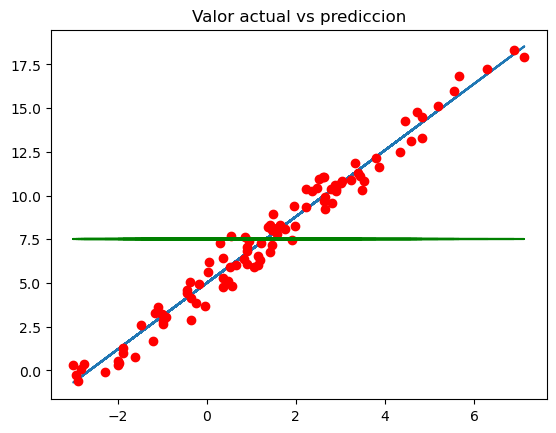

In [11]:
plt.plot(x,y_pred)
plt.plot(x,y_act,"ro")
plt.plot(x,y_mean,"g")
plt.title("Valor actual vs prediccion")

In [12]:
data["SSR"] = (data["y_prediccion"] - np.mean(y_act))**2
data["SSD"] = (data["y_prediccion"] - data["y_actual"])**2
data["SST"] = (data["y_actual"] - np.mean(y_act))**2

In [13]:
SSR = sum(data["SSR"])
SST = sum(data["SST"])
SSD = sum(data["SSD"])

In [14]:
data.head()

,x,y_actual,y_prediccion,SSR,SSD,SST
0,0.537853,7.678995,6.021922,2.293121,2.745894,0.020383
1,5.195634,15.146333,14.871706,53.809243,0.075420,57.913716
2,4.453570,14.267833,13.461784,35.112218,0.649715,45.314513
3,3.016955,10.709540,10.732215,10.214340,0.000514,10.069911
4,3.389773,11.286357,11.440569,15.243884,0.023781,14.063471


In [15]:
SSR + SSD

1933.6078906197204

In [16]:
SST

1967.9555429371205

In [17]:
SSR/SST

0.9563097990789517

### Encontrando los valores optimos

In [18]:
x_mean = np.mean(data["x"])
y_mean = np.mean(data["y_actual"])

In [19]:
x_mean, y_mean

(np.float64(1.3496991936384841), np.float64(7.5362271426099445))

In [20]:
data["beta_n"] = (data["x"] - x_mean) * (data["y_actual"] - y_mean)
data["beta_d"] = (data["x"] - x_mean)**2

In [21]:
beta = sum(data["beta_n"])/sum(data["beta_d"])

In [22]:
alpha = y_mean - beta * x_mean

In [23]:
alpha,beta

(np.float64(4.9482878058791675), 1.917419339752495)

El modelo lineal obtenido por regresion sera igual a: y = 5.037090649424213 + 1.905343697616636 * x

In [24]:
data["y_model"] = alpha + beta * data["x"]
data.head()

,x,y_actual,y_prediccion,SSR,SSD,SST,beta_n,beta_d,y_model
0,0.537853,7.678995,6.021922,2.293121,2.745894,0.020383,-0.115906,0.659093,5.979578
1,5.195634,15.146333,14.871706,53.809243,0.075420,57.913716,29.267976,14.791218,14.910498
2,4.453570,14.267833,13.461784,35.112218,0.649715,45.314513,20.894036,9.634016,13.487650
3,3.016955,10.709540,10.732215,10.214340,0.000514,10.069911,5.290725,2.779743,10.733056
4,3.389773,11.286357,11.440569,15.243884,0.023781,14.063471,7.650541,4.161901,11.447904


In [25]:
SSR = sum((data["y_model"] - y_mean)**2)
SSD = sum((data["y_model"] - data["y_actual"])**2)
SST = sum((data["y_actual"] - np.mean(y_act))**2)
SSR,SSD,SST

(1916.56053370663, 51.395009230490395, 1967.9555429371205)

In [26]:
R2 = SSR/SST
R2

0.9738840598229241

Text(0.5, 1.0, 'Valor actual vs prediccion')

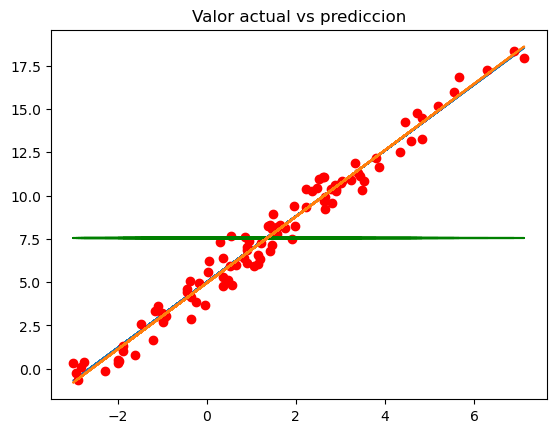

In [31]:
y_mean = [np.mean(y_act) for i in range(0,len(x_list))]
plt.plot(data["x"],data["y_prediccion"])
plt.plot(data["x"],data["y_actual"],"ro")
plt.plot(data["x"],y_mean,"g")
plt.plot(data["x"],data["y_model"])
plt.title("Valor actual vs prediccion")